# 2. Perceptrons: one neuron, then several

In notebook 1 we fitted a line to points. A neuron does almost exactly the
same arithmetic -- but instead of *drawing* a line through the data, it uses
the line to *split* the data in two.

In [2]:
!wget -O workshop_utils.py https://raw.githubusercontent.com/wjpearson/vistula/main/arazim/workshop_utils.py

--2026-09-22 10:27:41--  https://raw.githubusercontent.com/wjpearson/vistula/main/arazim/workshop_utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3487 (3.4K) [text/plain]
Saving to: ‘workshop_utils.py’

workshop_utils.py   100%[===================>]   3.41K  --.-KB/s    in 0s      

2026-09-22 10:27:41 (50.4 MB/s) - ‘workshop_utils.py’ saved [3487/3487]



In [4]:
# --- setup ------------------------------------------------
import sys, os, urllib.request

sys.path.append("..")          # if you cloned the repo, the helper is one level up
if not os.path.exists("workshop_utils.py") and "workshop_utils" not in sys.modules:
    try:
        import workshop_utils
    except ImportError:        # we are on Colab: fetch the helper
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/ShrRa/vistula_workshop/main/workshop_utils.py",
            "workshop_utils.py")

import numpy as np
import matplotlib.pyplot as plt
import workshop_utils as wu

np.random.seed(0)   # so that everyone in the room sees the same plots
plt.rcParams["figure.figsize"] = (5, 4)

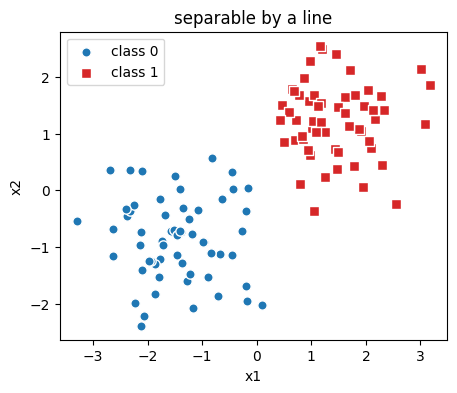

In [5]:
# --- our dataset for sections 1-3: two blobs, one line apart ---------------
n = 60
blob0 = np.random.randn(n, 2) * 0.7 + np.array([-1.5, -1.0])
blob1 = np.random.randn(n, 2) * 0.7 + np.array([1.5, 1.2])
X = np.vstack([blob0, blob1])
y = np.hstack([np.zeros(n), np.ones(n)])

wu.plot_points(X, y)
plt.legend()
plt.title("separable by a line")
plt.show()

## 1. The 1958 perceptron (Rosenblatt)

Compute $z = w_1x_1 + w_2x_2 + b$, output **1** if $z > 0$ and **0** otherwise, and
whenever you get an example wrong, shove the weights towards getting it right:

$$w \leftarrow w + \eta\,(y_{\text{true}} - y_{\text{pred}})\,x$$

w = [0.101 0.058], b = 0.000, accuracy = 100%


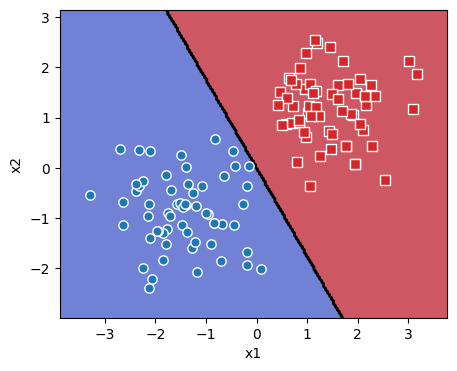

In [6]:
def step(z):
    return (z > 0).astype(float)

w, b = np.array([0.0, 0.0]), 0.0
for epoch in range(5):
    for xi, yi in zip(X, y):
        pred = step(np.dot(xi, w) + b)
        error = yi - pred           # -1, 0 or +1
        w = w + 0.05 * error * xi
        b = b + 0.05 * error

acc = np.mean(step(X @ w + b) == y)
print(f"w = {w.round(3)}, b = {b:.3f}, accuracy = {acc:.0%}")

wu.plot_boundary(lambda G: step(G @ w + b), X, y)
plt.show()

Problem: the `step` function is a cliff. Its slope is zero everywhere and
undefined at the edge -- so there is **no gradient to descend**.
The fix is to replace the cliff with a **sigmoid**,

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

which slides smoothly from 0 to 1, and therefore has a slope everywhere.

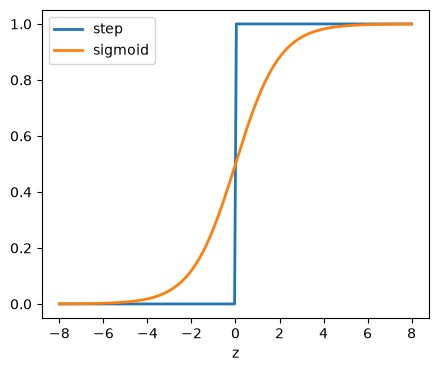

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

zs = np.linspace(-8, 8, 200)
plt.plot(zs, step(zs), lw=2, label="step")
plt.plot(zs, sigmoid(zs), lw=2, label="sigmoid")
plt.legend()
plt.xlabel("z")
plt.show()

## 2. One neuron, by hand

A neuron:

$$z = \mathbf{w}\cdot\mathbf{x} + b \qquad\quad a = \sigma(z)$$

**Weights** $\mathbf{w}$ rotate the boundary, the **bias** $b$ shifts it away
from the origin, and $a$ is the output: a number between 0 and 1 that we read
as "how confident am I that this point is class 1".

In [ ]:
def neuron(X, w, b):
    """Forward pass of a single sigmoid neuron on a batch of points."""
    return sigmoid(X @ w + b)

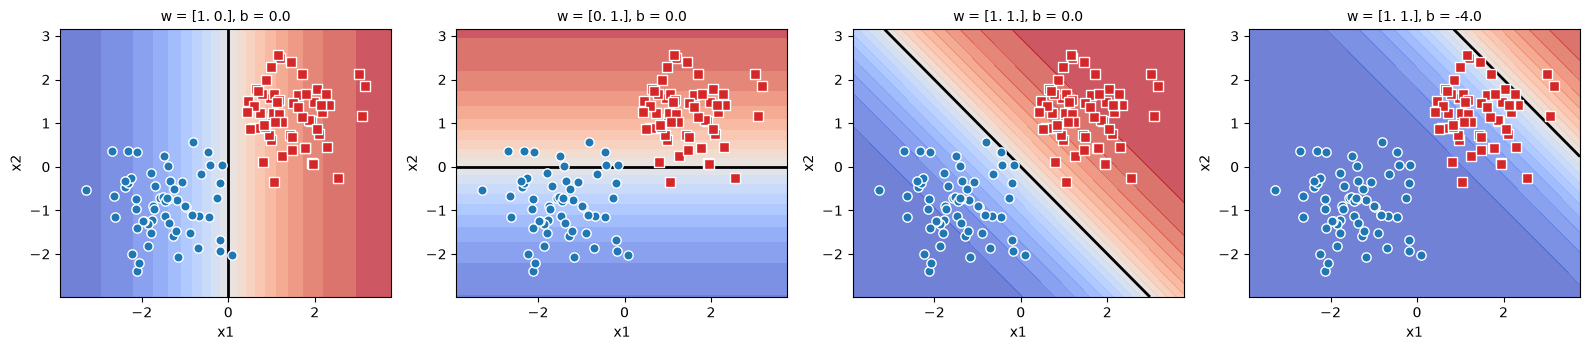

In [ ]:
# Four hand-picked settings. Change the numbers and re-run
settings = [(np.array([1.0, 0.0]),  0.0),
            (np.array([0.0, 1.0]),  0.0),
            (np.array([1.0, 1.0]),  0.0),
            (np.array([1.0, 1.0]), -4.0)]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (w_try, b_try) in zip(axes, settings):
    wu.plot_boundary(lambda G: neuron(G, w_try, b_try), X, y, ax=ax,
                     title=f"w = {w_try}, b = {b_try}")
plt.tight_layout()
plt.show()

Panels 1-3: only the *direction* of `w` changed, and the boundary
rotated. Compare 3 and 4: only `b` changed, and the boundary slid sideways
without turning.

The colour gradient is sharper when `w` is larger. The
**length** of `w` controls how confident the neuron is near the boundary. A
network that is overconfident and wrong usually has weights that grew too big
(look up L2 regularization in your spare time, aka 'keep the weights as small as possible').

## 3. Training it properly

To descend, we need a loss. Squared error works but trains slowly for
classification; the standard choice is **binary cross-entropy**, which
punishes confident mistakes very harshly:

$$L = -\frac{1}{N}\sum_i \Big[ y_i \log a_i + (1-y_i)\log(1-a_i) \Big]$$

$\log(1) = 0$ and $\log(\text{something tiny}) \to -\infty$. So
if you say 0.99 and you are right, you pay nothing; if you say 0.01 and you
are wrong, you pay enormously.

Note that the loss is a function of `params = [w1, w2, b]`, which is exactly the
setup from notebook 1, so we can reuse `gradient_descent_nd` unchanged.

In [ ]:
def numerical_gradient_nd(f, x, h=1e-5):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        step_i = np.zeros_like(x);
        step_i[i] = h
        grad[i] = (f(x + step_i) - f(x - step_i)) / (2 * h)
    return grad

def gradient_descent_nd(f, x0, lr=0.1, n_steps=30):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    for _ in range(n_steps):
        x = x - lr * numerical_gradient_nd(f, x)
        path.append(x.copy())
    return np.array(path)


def bce_loss(params):
    """params = [w1, w2, b] -> a single number saying how wrong we are."""
    w, b = params[:2], params[2]
    a = neuron(X, w, b)
    a = np.clip(a, 1e-9, 1 - 1e-9)     # keep log() away from zero
    return -np.mean(y * np.log(a) + (1 - y) * np.log(1 - a))


learned w = [4.58 2.57], b = -1.14
loss: 0.693  ->  0.006


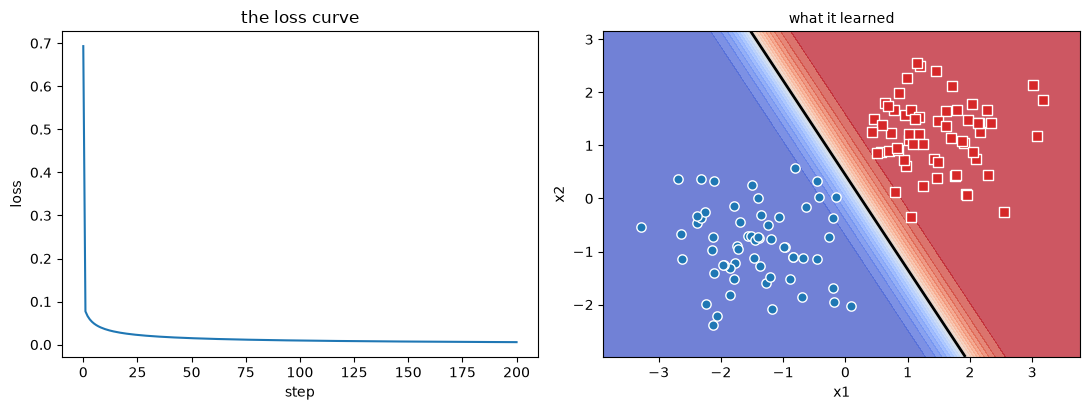

In [ ]:
trail = gradient_descent_nd(bce_loss, x0=[0.0, 0.0, 0.0], lr=2.0, n_steps=200)
w_fit, b_fit = trail[-1][:2], trail[-1][2]
print(f"learned w = {w_fit.round(2)}, b = {b_fit:.2f}")
print(f"loss: {bce_loss(trail[0]):.3f}  ->  {bce_loss(trail[-1]):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot([bce_loss(p) for p in trail])
ax1.set_xlabel("step"); ax1.set_ylabel("loss"); ax1.set_title("the loss curve")
wu.plot_boundary(lambda G: neuron(G, w_fit, b_fit), X, y, ax=ax2,
                 title="what it learned")
plt.tight_layout()
plt.show()

That loss curve first drops fast, then flattens. The sharper the drop, the better. If your model flattens well above loss=0,
work on model architecture.

## 4. **XOR** challenge

Four points. Class 1 when the coordinates *differ*, class 0 when they agree.
This is **XOR**, no straight line can separate it, and so far we only produced straight lines.

In [ ]:
X_xor = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = np.array([0.0, 1.0, 1.0, 0.0])

def bce_xor(params):
    w, b = params[:2], params[2]
    a = np.clip(neuron(X_xor, w, b), 1e-9, 1 - 1e-9)
    return -np.mean(y_xor * np.log(a) + (1 - y_xor) * np.log(1 - a))

In [ ]:
trail = gradient_descent_nd(bce_xor, x0=[1.2, -0.7, 0.4], lr=1.0, n_steps=400)
w_x, b_x = trail[-1][:2], trail[-1][2]
print(f"final loss {bce_xor(trail[-1]):.4f}  (0.693 = pure guessing)")
print("predictions:", neuron(X_xor, w_x, b_x).round(2), " should be", y_xor)

final loss 0.6931  (0.693 = pure guessing)
predictions: [0.5 0.5 0.5 0.5]  should be [0. 1. 1. 0.]


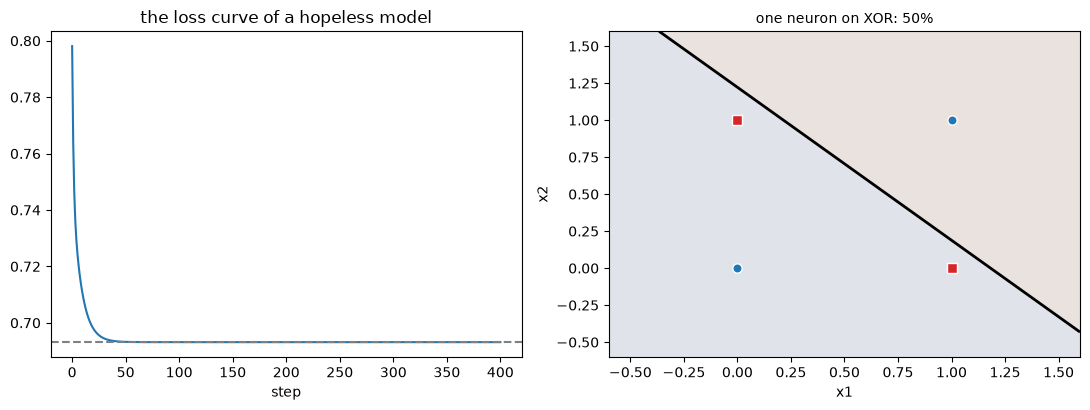

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot([bce_xor(p) for p in trail]); ax1.axhline(np.log(2), ls="--", c="0.5")
ax1.set_title("the loss curve of a hopeless model"); ax1.set_xlabel("step")
wu.plot_boundary(lambda G: neuron(G, w_x, b_x), X_xor, y_xor, ax=ax2,
                 title="one neuron on XOR: 50%")
plt.tight_layout()
plt.show()

The neuron ends up saying **0.5 to everything**. It worked out that any line it draws gets two points
right and two wrong. The loss
settles at $\log 2 = 0.693$ (loss value for random guessing for this dataset).

The model is too weak for this data.


## 5. Three neurons, wired together

If one line cannot do it, use two lines and then *combine* them.

* hidden neuron 1 learns **OR**: is at least one coordinate high?
* hidden neuron 2 learns **AND**: are both coordinates high?
* the output neuron learns **OR but not AND** -- which is XOR.

That is a 2-2-1 network: two inputs, two hidden neurons, one output. In code
it is the single-neuron line, twice:

```
a1 = sigmoid(X  @ W1 + b1)     # hidden layer, shape (N, 2)
a2 = sigmoid(a1 @ W2 + b2)     # output layer, shape (N, 1)
```

Fill in the six weights and three biases below. Hints: sigmoid
is ~1 when `z` is around +10 and ~0 when `z` is around -10, so use weights of
about 20 and biases that set the threshold. For OR, one high input should be
enough to clear the bar; for AND, it should take two.

In [ ]:
def forward(X, W1, b1, W2, b2):
    """Forward pass of a 2-2-1 network. No training here -- just arithmetic."""
    a1 = sigmoid(X @ W1 + b1)      # (N, 2) : what the hidden neurons say
    a2 = sigmoid(a1 @ W2 + b2)     # (N, 1) : what the network says
    return a1, a2


# Columns of W1 are the two hidden neurons: the 1st should learn OR, the 2nd AND.
W1 = np.array([[20.0, 20.0], [20.0, 20.0]])
b1 = np.array([-10.0, -30.0])
W2 = np.array([[20.0], [-20.0]])
b2 = np.array([-10.0])

a1, a2 = forward(X_xor, W1, b1, W2, b2)
print("hidden layer (OR, AND):\n", a1.round(2))
print("network output:", a2.ravel().round(3), " should be", y_xor)

hidden layer (OR, AND):
 [[0. 0.]
 [1. 0.]
 [1. 0.]
 [1. 1.]]
network output: [0. 1. 1. 0.]  should be [0. 1. 1. 0.]


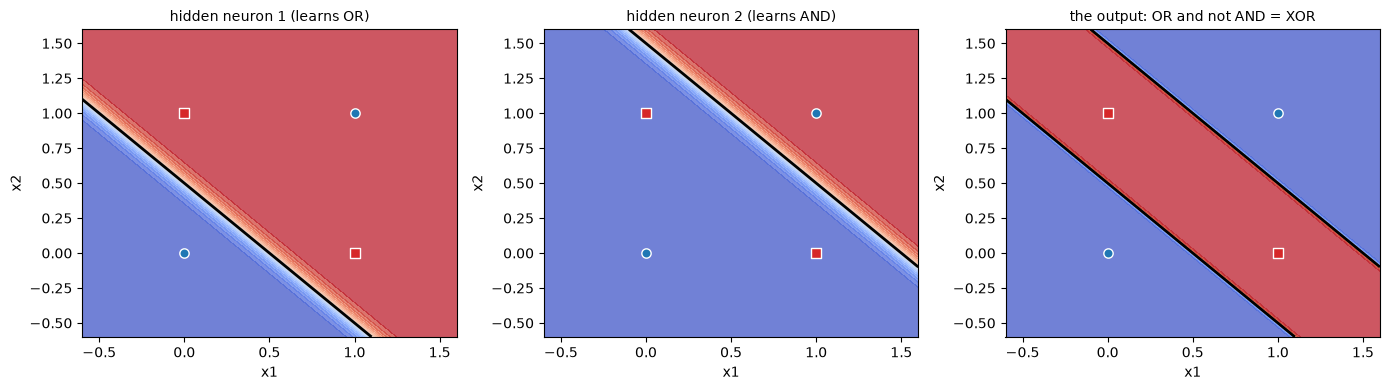

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
wu.plot_boundary(lambda G: forward(G, W1, b1, W2, b2)[0][:, 0], X_xor, y_xor,
                 ax=axes[0], title="hidden neuron 1 (learns OR)")
wu.plot_boundary(lambda G: forward(G, W1, b1, W2, b2)[0][:, 1], X_xor, y_xor,
                 ax=axes[1], title="hidden neuron 2 (learns AND)")
wu.plot_boundary(lambda G: forward(G, W1, b1, W2, b2)[1].ravel(), X_xor, y_xor,
                 ax=axes[2], title="the output: OR and not AND = XOR")
plt.tight_layout()
plt.show()

Add enough layers, and you can model really complex data. Unless something goes wrong :D

## An extra: making the layer a class

In [ ]:
class Layer:
    def __init__(self, n_in, n_out):
        self.W = np.random.randn(n_in, n_out) * 0.5
        self.b = np.zeros(n_out)

    def forward(self, X):
        return sigmoid(X @ self.W + self.b)


hidden = Layer(2, 2); output = Layer(2, 1)
hidden.W, hidden.b, output.W, output.b = W1, b1, W2, b2   # our hand-set values

print(output.forward(hidden.forward(X_xor)).ravel().round(3))

[0. 1. 1. 0.]
